# Thompson-Konstruktion für reguläre Ausdrücke

Willkommen zum Workshop! In diesem Notebook lernst du, wie man die **Thompson-Konstruktion** implementiert. Das ist ein eleganter Algorithmus, der einen regulären Ausdruck (den wir zuerst in einen sogenannten AST - Abstract Syntax Tree - zerlegen) in einen nicht-deterministischen endlichen Automaten (NFA) verwandelt.

Keine Sorge, wenn du noch nie von Automaten gehört hast – wir gehen alles Schritt für Schritt durch. Wir nutzen zwei kleine Python-Pakete:
1. `ast_parser`: Liest deinen Regex-String und baut daraus einen Strukturbaum (AST).
2. `automaton`: Liefert uns die Bausteine für den Automaten (Zustände und Übergänge) und einen Executor, um zu testen, ob der Automat funktioniert.

In [1]:
!pip install graphviz
import sys

sys.path.append('.')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import graphviz
from ast_parser import regex_parsen, Literal, Concatenation, Alternation, Star, ast_to_dot
from automaton import State, NFA, NFAExecutor, nfa_to_dot

## Unser Werkzeug: Die Visualisierungsfunktion

Damit du siehst, was im Hintergrund passiert, nutzen wir diese Funktion. Sie zeichnet uns den AST (wie der Regex verstanden wurde) und den NFA (den daraus resultierenden Automaten).

In [3]:
def regex_visualisieren(pattern, build_func=None, parse_func=regex_parsen):
    ast = parse_func(pattern)
    print(f"Muster: {pattern}")

    print("\n--- AST (Strukturbaum) ---")
    display(graphviz.Source(ast_to_dot(ast)))

    if build_func:
        nfa = build_func(ast, [0])
        print("\n--- NFA (Automat) ---")
        display(graphviz.Source(nfa_to_dot(nfa)))
    else:
        print("\n--- NFA noch nicht erstellt (keine build_func angegeben) ---")

## Schritt 1: Literale (Einzelzeichen)

Ein **Literal** ist das einfachste Element: ein einzelnes Zeichen, z.B. `'a'`.

Schau dir zuerst an, wie der Parser ein einzelnes Zeichen als AST darstellt:

Muster: ab(c|d)*

--- AST (Strukturbaum) ---


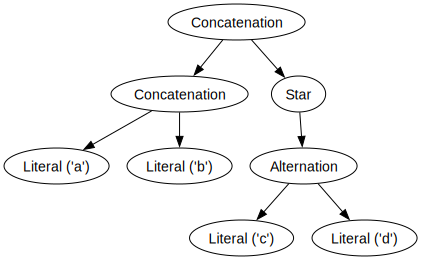


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [26]:
regex_visualisieren("ab(c|d)*")

### Das Bauprinzip für Literale

Für ein Literal `a` erstellen wir zwei Zustände: einen Startzustand und einen akzeptierenden Endzustand. Wir verbinden sie mit einem Pfeil, der mit dem Zeichen `a` beschriftet ist.

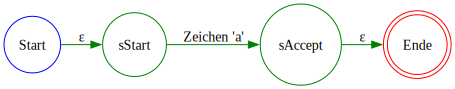

In [5]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; s0 [label="Start", color=blue]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; s1 [label="Ende", shape=doublecircle, color=red]; s0 -> sStart [label="ε", color=green]; sStart -> sAccept [label="Zeichen \'a\'", color=green]; sAccept -> s1 [label="ε", color=green]; }'))

**Deine Aufgabe**: Implementiere den ersten Teil von `nfa_bauen`. Wir fangen nur mit `Literal` an.

In [6]:
def neuer_zustand(counter):
    name = f"s{counter[0]}"
    counter[0] += 1
    return State(name)


def nfa_bauen(node, state_counter):
    transformiert = knoten_transformieren(node, state_counter)

    if transformiert is None:
        raise TypeError(f"Diesen Knotentyp können wir noch nicht verarbeiten: {type(node)}")
    else:
        return transformiert

Muster: a

--- AST (Strukturbaum) ---


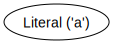


--- NFA (Automat) ---


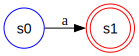

In [7]:
def literal_transformieren(node, state_counter=None):
    # TODO: Implementiere die Konstruktion für ein Literal
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(node.char, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    return None


# Teste dein Ergebnis:
regex_visualisieren("a", build_func=nfa_bauen)

## Schritt 2: Konkatenation (Hintereinander)

Wenn wir zwei Zeichen hintereinander haben (z.B. `ab`), nennt man das **Konkatenation**. Im AST siehst du dann einen `Concatenation`-Knoten, der zwei Unterbäume hat.

Schau dir den AST für `ab` an:

Muster: ab

--- AST (Strukturbaum) ---


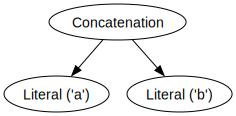


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [8]:
regex_visualisieren("ab")

### Das Bauprinzip für Konkatenation

Um `AB` zu bauen, bauen wir erst den Automaten für `A` und den für `B`. Dann verbinden wir den Endzustand von `A` mit dem Startzustand von `B` über einen sogenannten **Epsilon-Übergang** (ein Übergang, der kein Zeichen benötigt, in unserem Code durch `None` dargestellt).

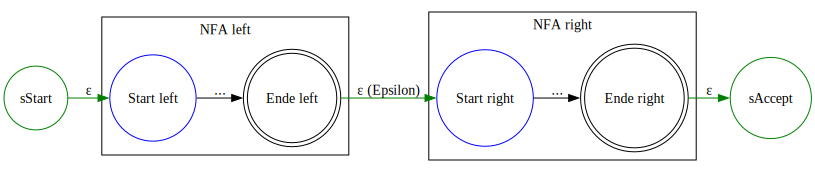

In [9]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; subgraph cluster_left { label="NFA left"; sL0 [label="Start left", color=blue]; sL1 [label="Ende left", shape=doublecircle]; sL0 -> sL1 [label="..."]; } subgraph cluster_right { label="NFA right"; sR0 [label="Start right", color=blue]; sR1 [label="Ende right", shape=doublecircle]; sR0 -> sR1 [label="..."]; } sStart -> sL0 [label="ε", color=green]; sL1 -> sR0 [label="ε (Epsilon)", color=green]; sR1 -> sAccept [label="ε", color=green]; }'))

**Deine Aufgabe**: Erweitere `nfa_bauen`, um `Concatenation` zu unterstützen.

Muster: ab

--- AST (Strukturbaum) ---


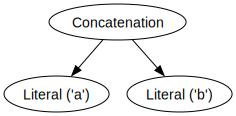


--- NFA (Automat) ---


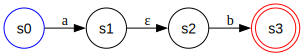

In [10]:
def concatenation_transformieren(node, state_counter):
    # TODO Implementiere die Konstruktion für Concatenation
    links = nfa_bauen(node.left, state_counter)
    rechts = nfa_bauen(node.right, state_counter)
    links.accept_state.add_transition(None, rechts.start_state)
    return NFA(links.start_state, rechts.accept_state)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    return None


# Teste dein Ergebnis:
regex_visualisieren("ab", build_func=nfa_bauen)

## Schritt 3: Alternation (Oder / Auswahl)

Mit dem Zeichen `|` können wir sagen: "Entweder das oder das" (z.B. `a|b`). Im AST erscheint dies als `Alternation`-Knoten.

Schau dir den AST für `a|b` an:

Muster: a|b

--- AST (Strukturbaum) ---


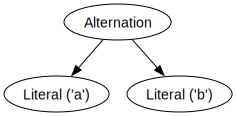


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [11]:
regex_visualisieren("a|b")

### Das Bauprinzip für Alternation

Für `A|B` erstellen wir einen neuen Startzustand, von dem aus wir per Epsilon-Übergang entweder zum Start von `A` oder zum Start von `B` springen können. Ebenso führen die Endzustände von `A` und `B` per Epsilon-Übergang zu einem gemeinsamen neuen Endzustand.

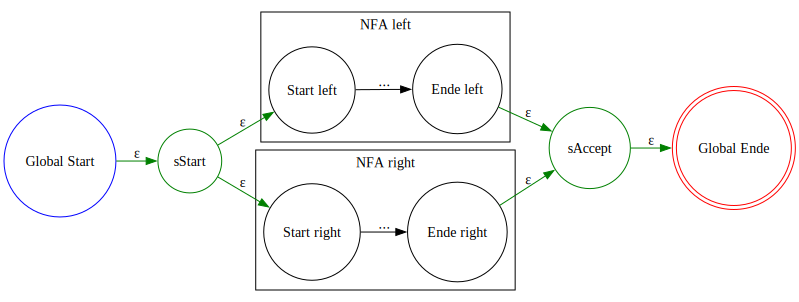

In [12]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sGlobalStart [label="Global Start", color=blue]; sGlobalEnd [label="Global Ende", shape=doublecircle, color=red]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; subgraph cluster_left { label="NFA left"; sL0 [label="Start left"]; sL1 [label="Ende left"]; sL0 -> sL1 [label="..."]; } subgraph cluster_right { label="NFA right"; sR0 [label="Start right"]; sR1 [label="Ende right"]; sR0 -> sR1 [label="..."]; } sGlobalStart -> sStart [label="ε", color=green]; sStart -> sL0 [label="ε", color=green]; sStart -> sR0 [label="ε", color=green]; sL1 -> sAccept [label="ε", color=green]; sR1 -> sAccept [label="ε", color=green]; sAccept -> sGlobalEnd [label="ε", color=green]; }'))

**Deine Aufgabe**: Erweitere `nfa_bauen` um `Alternation`.

Muster: a|b

--- AST (Strukturbaum) ---


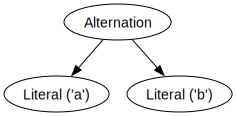


--- NFA (Automat) ---


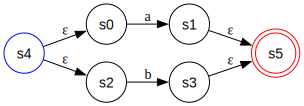

In [13]:
def alternation_transformieren(node, state_counter):
    # TODO Implementiere die Konstruktion für Alternation
    links = nfa_bauen(node.left, state_counter)
    rechts = nfa_bauen(node.right, state_counter)
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(None, links.start_state)
    start.add_transition(None, rechts.start_state)
    links.accept_state.add_transition(None, accept)
    rechts.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    return None


# Teste dein Ergebnis:
regex_visualisieren("a|b", build_func=nfa_bauen)

## Schritt 4: Der Kleene-Stern (Wiederholung)

Der Stern `*` bedeutet: "Nullmal oder beliebig oft". Im AST ist das ein `Star`-Knoten, der einen anderen Ausdruck umschließt.

Schau dir den AST für `a*` an:

Muster: a*

--- AST (Strukturbaum) ---


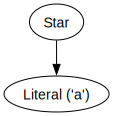


--- NFA noch nicht erstellt (keine build_func angegeben) ---


In [14]:
regex_visualisieren("a*")

### Das Bauprinzip für den Stern

Für `A*` brauchen wir einen neuen Start- und Endzustand, um zwei Dinge zu ermöglichen:
1. **Wiederholung**: Der Endzustand von `A` führt zurück zum Start von `A`.
2. **Überspringen**: Der Startzustand kann direkt zum Endzustand springen (wenn das Zeichen 0-mal vorkommt).

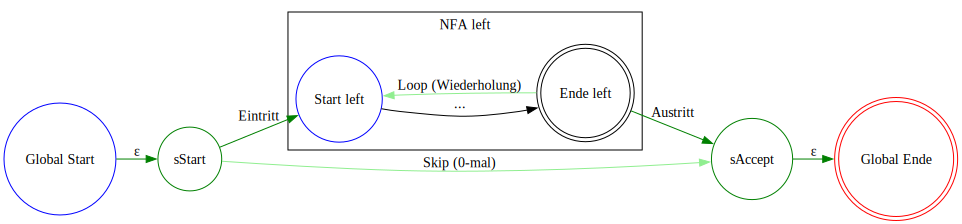

In [15]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sGlobalStart [label="Global Start", color=blue]; sGlobalEnd [label="Global Ende", shape=doublecircle, color=red]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; subgraph cluster_left { label="NFA left"; sL0 [label="Start left", color=blue]; sL1 [label="Ende left", shape=doublecircle]; sL0 -> sL1 [label="..."]; } sGlobalStart -> sStart [label="ε", color=green]; sStart -> sL0 [label="Eintritt", color=green]; sL1 -> sL0 [label="Loop (Wiederholung)", color=lightgreen]; sL1 -> sAccept [label="Austritt", color=green]; sStart -> sAccept [label="Skip (0-mal)", color=lightgreen]; sAccept -> sGlobalEnd [label="ε", color=green]; }'))

**Deine Aufgabe**: Vervollständige `nfa_bauen` für den `Star`-Knoten.

Muster: a*

--- AST (Strukturbaum) ---


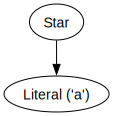


--- NFA (Automat) ---


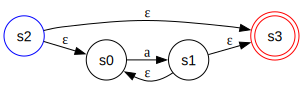

In [16]:
def star_transformieren(node, state_counter):
    # TODO: Implementiere die Konstruktion für Star
    inner = nfa_bauen(node.expression, state_counter)
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(None, inner.start_state)
    start.add_transition(None, accept)
    inner.accept_state.add_transition(None, inner.start_state)
    inner.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    elif isinstance(node, Star):
        return star_transformieren(node, state_counter)
    return None


# Teste dein Ergebnis:
regex_visualisieren("a*", build_func=nfa_bauen)

## Finale Tests

Jetzt, wo du alle Grundbausteine hast, testen wir deinen Automaten mit verschiedenen Mustern und Texten.

In [17]:
def regex_testen(pattern, text, expected):
    ast = regex_parsen(pattern)
    nfa = nfa_bauen(ast, [0])
    executor = NFAExecutor(nfa)
    result = executor.execute(text)
    print(f"Muster: {pattern}, Text: {text}, Erwartet: {expected}, Ergebnis: {result}")
    assert result == expected


regex_testen("a", "a", True)
regex_testen("a", "b", False)
regex_testen("a|b", "a", True)
regex_testen("a|b", "b", True)
regex_testen("a|b", "c", False)
regex_testen("a*", "", True)
regex_testen("a*", "aaaa", True)
regex_testen("a*", "b", False)
regex_testen("ab", "ab", True)
regex_testen("ab", "a", False)
regex_testen("(a|b)*c", "ababac", True)
regex_testen("(a|b)*c", "ababc", True)
regex_testen("(a|b)*c", "abab", False)
print("\nAlle Tests bestanden! Super gemacht!")

Muster: a, Text: a, Erwartet: True, Ergebnis: True
Muster: a, Text: b, Erwartet: False, Ergebnis: False
Muster: a|b, Text: a, Erwartet: True, Ergebnis: True
Muster: a|b, Text: b, Erwartet: True, Ergebnis: True
Muster: a|b, Text: c, Erwartet: False, Ergebnis: False
Muster: a*, Text: , Erwartet: True, Ergebnis: True
Muster: a*, Text: aaaa, Erwartet: True, Ergebnis: True
Muster: a*, Text: b, Erwartet: False, Ergebnis: False
Muster: ab, Text: ab, Erwartet: True, Ergebnis: True
Muster: ab, Text: a, Erwartet: False, Ergebnis: False
Muster: (a|b)*c, Text: ababac, Erwartet: True, Ergebnis: True
Muster: (a|b)*c, Text: ababc, Erwartet: True, Ergebnis: True
Muster: (a|b)*c, Text: abab, Erwartet: False, Ergebnis: False

Alle Tests bestanden! Super gemacht!


## Bonus: Den Parser erweitern

Unser Parser ist so gebaut, dass du ganz einfach neue Symbole hinzufügen kannst, ohne den Kerncode ändern zu müssen. Wir nutzen dafür die `postfix_handlers`.

### Aufgabe: Den `?` (Optional) Operator hinzufügen

Das Zeichen `?` bedeutet "null oder einmal".
1. Wir nutzen den bereits existierenden `Optional`-Knoten in `ast_nodes.py`.
2. Wir sagen dem Parser, dass er das Zeichen `?` als `Optional`-Knoten behandeln soll.
3. Wir erweitern die NFA-Logik.

**Tipp**: Ein optionales `A?` ist fast wie `A*`, nur dass es keine Schleife zurück zum Start von `A` gibt.

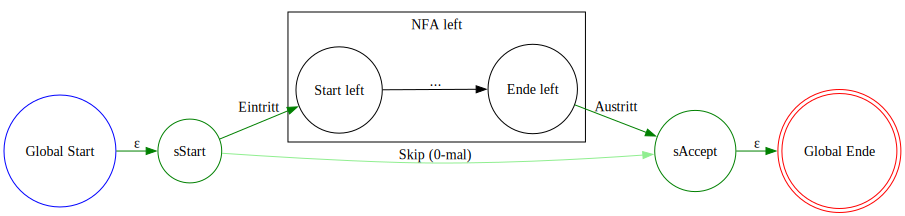

In [18]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; sGlobalStart [label="Global Start", color=blue]; sGlobalEnd [label="Global Ende", shape=doublecircle, color=red]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; subgraph cluster_A { label="NFA left"; sA0 [label="Start left"]; sA1 [label="Ende left"]; sA0 -> sA1 [label="..."]; } sGlobalStart -> sStart [label="ε", color=green]; sStart -> sA0 [label="Eintritt", color=green]; sA1 -> sAccept [label="Austritt", color=green]; sStart -> sAccept [label="Skip (0-mal)", color=lightgreen]; sAccept -> sGlobalEnd [label="ε", color=green]; }'))

Muster: a?b

--- AST (Strukturbaum) ---


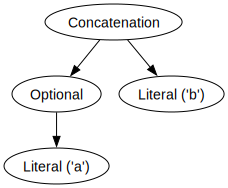


--- NFA (Automat) ---


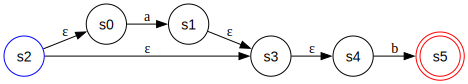

In [19]:
from ast_parser.parser import RegexParser
from ast_parser.ast_nodes import Optional


def regex_parsen(pattern):
    parser = RegexParser(pattern)
    # Wir ergänzen den Parser um das ?-Zeichen als Postfix-Operator
    parser.postfix_handlers['?'] = lambda node: Optional(node)
    return parser.parse()


def optional_transformieren(node, state_counter):
    # TODO: Implementiere die Konstruktion für Optional
    inner = nfa_bauen(node.expression, state_counter)
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    start.add_transition(None, inner.start_state)
    start.add_transition(None, accept)
    inner.accept_state.add_transition(None, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    elif isinstance(node, Star):
        return star_transformieren(node, state_counter)
    elif isinstance(node, Optional):
        return optional_transformieren(node, state_counter)
    return None


# Testen
regex_visualisieren("a?b", build_func=nfa_bauen, parse_func=regex_parsen)

### Herausforderung: Zeichengruppen `[a-z]`

Eine Zeichengruppe wie `[a-c]` ist ein eigenständiger Knoten im AST. Die Aufgabe ist es nun, diesen Knoten in einen NFA zu verwandeln.

**Bauprinzip**: Eine Gruppe `[a-c]` funktioniert wie eine Alternation (`a|b|c`). Du musst also für jedes Zeichen in der Gruppe einen Übergang vom Start- zum Endzustand erstellen.

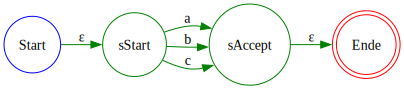

In [25]:
display(graphviz.Source(
    'digraph { rankdir=LR; node [shape=circle]; s0 [label="Start", color=blue]; s1 [label="Ende", shape=doublecircle, color=red]; sStart [label="sStart", color=green]; sAccept [label="sAccept", color=green]; s0 -> sStart [label="ε", color=green]; sStart -> sAccept [label="a", color=green]; sStart -> sAccept [label="b", color=green]; sStart -> sAccept [label="c", color=green]; sAccept -> s1 [label="ε", color=green]; }'))

In [21]:
from ast_parser.ast_nodes import CharacterGroup


def handle_char_group(p):
    if p.peek() == '[':
        p.consume()  # '['
        chars = []
        while p.peek() and p.peek() != ']':
            char = p.consume()
            if p.peek() == '-' and p.pos + 1 < len(p.pattern) and p.pattern[p.pos + 1] != ']':
                p.consume()  # '-'
                end_char = p.consume()
                for c in range(ord(char), ord(end_char) + 1):
                    chars.append(chr(c))
            else:
                chars.append(char)
        if p.consume() != ']':
            raise ValueError("Erwartetes ']' fehlt")
        return CharacterGroup(chars)
    return None


def regex_parsen(pattern):
    parser = RegexParser(pattern)
    parser.postfix_handlers['?'] = lambda node: Optional(node)
    # Wir erweitern den Parser um die Unterstützung von CharacterGroup
    parser.atom_handlers.insert(0, handle_char_group)
    return parser.parse()


def chargroup_transformieren(node, state_counter):
    # TODO: Implementiere die Konstruktion für CharacterGroup
    start = neuer_zustand(state_counter)
    accept = neuer_zustand(state_counter)
    for char in node.chars:
        start.add_transition(char, accept)
    return NFA(start, accept)


def knoten_transformieren(node, state_counter):
    if isinstance(node, Literal):
        return literal_transformieren(node, state_counter)
    elif isinstance(node, Concatenation):
        return concatenation_transformieren(node, state_counter)
    elif isinstance(node, Alternation):
        return alternation_transformieren(node, state_counter)
    elif isinstance(node, Star):
        return star_transformieren(node, state_counter)
    elif isinstance(node, Optional):
        return optional_transformieren(node, state_counter)
    elif isinstance(node, CharacterGroup):
        return chargroup_transformieren(node, state_counter)
    return None

### Die Zeichengruppen testen

Probier es aus mit `[a-c]d`!

Muster: [a-c]d

--- AST (Strukturbaum) ---


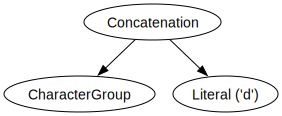


--- NFA (Automat) ---


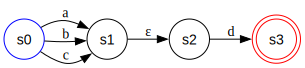

In [22]:
regex_visualisieren("[a-c]d", build_func=nfa_bauen, parse_func=regex_parsen)

### Herausforderung für Profis

Wenn du noch Zeit hast, versuche folgende Dinge einzubauen:
- `+` (Eins oder mehr): Ähnlich wie `?` und `*`.
- `{n,m}` (Wiederholung): Hier musst du einen komplexeren Handler schreiben, der die Zahlen im String ausliest.
- Negierte Gruppen `[^a-z]`: Alles außer den angegebenen Zeichen.

In [23]:
# TODO Spielwiese